In [1]:
from math import pi
import matplotlib.pyplot as plt
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeBrisbane
from qiskit_ibm_runtime import QiskitRuntimeService

In [3]:
# Initialize the Qiskit Runtime Service

from test_utils import read_account_file
account = read_account_file('account_info.conf') 
# Ensure the account file is read correctly
#print("Account details:", account)

service = QiskitRuntimeService(channel="ibm_cloud",instance=account["instance"],token=account["token"])
backend = service.least_busy()
print(f"Using backend: {backend.name}")

Using backend: ibm_torino


In [4]:
nq = 3    # number of qubits
m = 3    # number of classical bits

PHI = pi/4

q = QuantumRegister(nq,'q')
c = ClassicalRegister(m,'c')

qc = QuantumCircuit(q,c)

qc.h(0)
qc.x([1, 2])

In [5]:
def x_measurement(qc, qubit, cbit):
    """Measure 'qubit' in the X-basis, and store the result in 'cbit'"""
    qc.h(qubit)
    qc.measure(qubit, cbit)

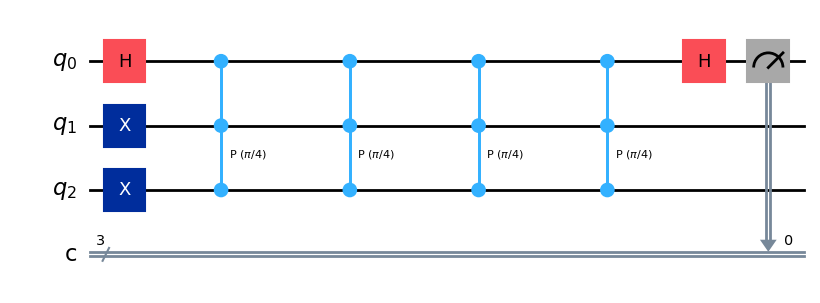

In [6]:
for _ in range(2 ** (m - 1)):
    qc.mcp(PHI, [0, 1], 2)

x_measurement(qc, q[0], c[0])
qc.draw('mpl')

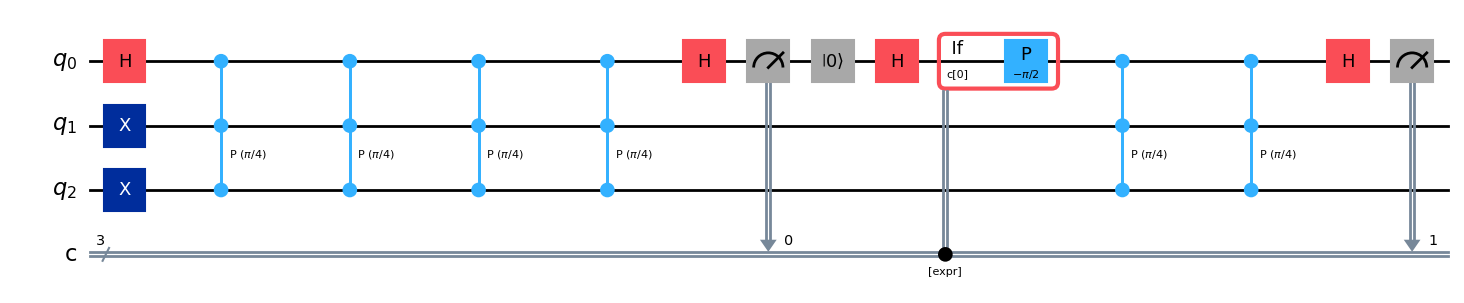

In [7]:
qc.reset(0)
qc.h(0)

with qc.if_test(expr.lift(c[0])):
    qc.p(-pi/2, 0) # phase correction

for _ in range(2 ** (m - 2)):
    qc.mcp(PHI, [0, 1], 2)
    
x_measurement(qc, q[0], c[1])
qc.draw('mpl')

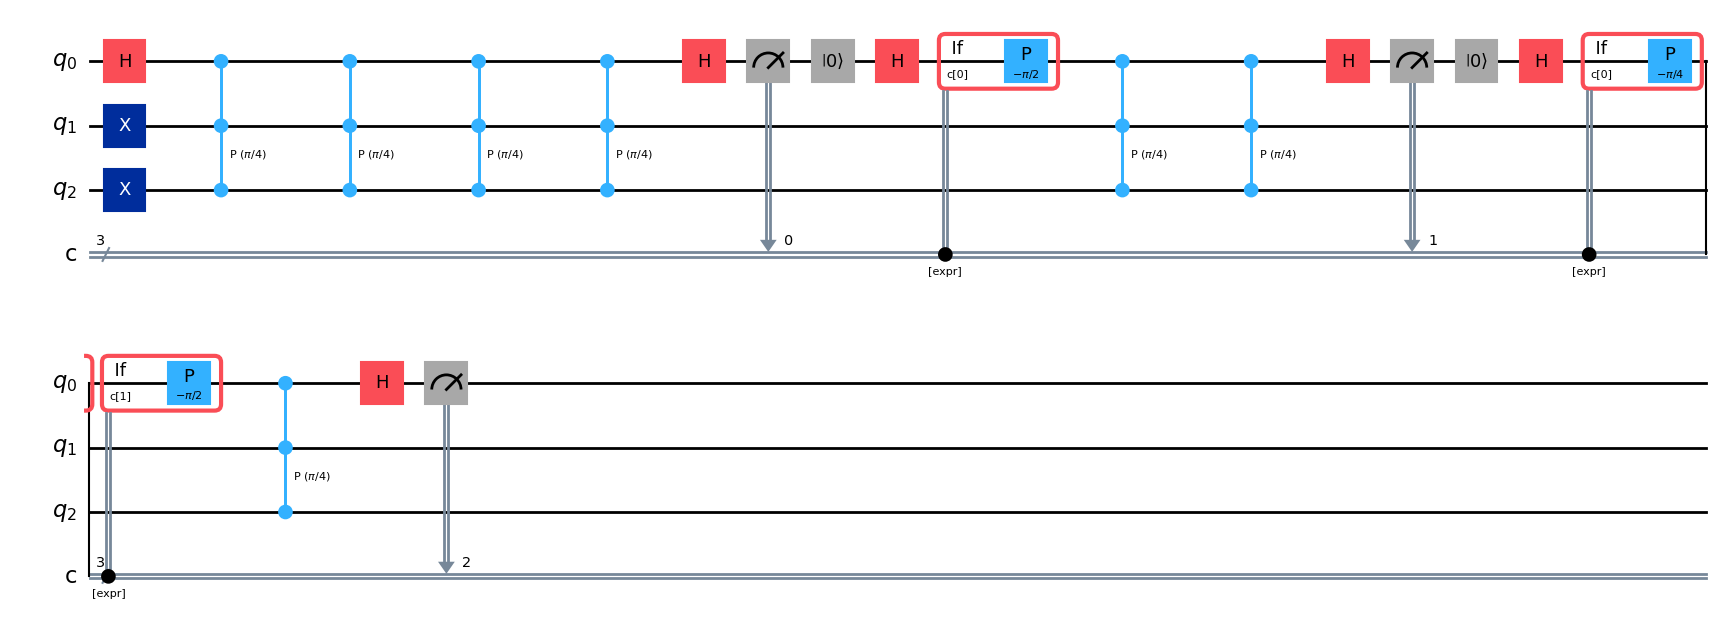

In [8]:
qc.reset(0)
qc.h(0)

# phase correction
first = expr.lift(c[0])
second = expr.lift(c[1])

with qc.if_test(first):
    qc.p(-pi/4, 0)

with qc.if_test(second):
    qc.p(-pi/2, 0)

# c-U operations
for _ in range(2 ** (m - 3)):
    qc.mcp(PHI, [0, 1], 2)

# X measurement  
qc.h(0)
qc.measure(0, 2)

qc.draw('mpl')

In [9]:
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

isa_circuit = pm.run(qc)

TranspilerError: "The control-flow construct 'if_else' is not supported by the backend."

In [ ]:
sampler = Sampler(mode=backend)

job = sampler.run([isa_circuit])

id = job.job_id()
print(id)

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
job = service.job(id)
job_result = job.result()
counts = job_result[0].data.c.get_counts()
plot_histogram(counts)

In [ ]:
# get the most frequent result
max_key, max_value = max(counts.items(), key=lambda x: x[1])

phi = int(max_key, 2) / 8

print(f'phi = {phi}') # 0.125 (= 1/8 = 0.001 in bynary) as expected